<a href="https://colab.research.google.com/github/gaeun-k/Class_ML/blob/main/auto_class_2_BayesianClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. 차선 검출

문제 1. Projection Matrix 해석

이 행렬이 어떤 의미를 가지는지 설명하고, 다음을 포함하여 해석하시오.
  - intrinsic 파라미터 (f_x, f_y, c_x, c_y)의 의미
  - extrinsic 파라미터 (R, t)의 역할
  - 이 행렬이 3D 점을 이미지 좌표로 어떻게 변환하는지 수식으로 설명

⸻

문제 2. Projection Matrix를 이용한 3D → 2D 투영

임의의 3차원 점들을 생성하고, projection matrix를 이용하여 이미지 좌표로 투영하시오.

투영된 점들을 이미지 위에 시각화하고, 결과가 카메라 투영의 특성과 어떻게 일치하는지 설명하시오.

⸻

문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 데이터를 이용하여 1번 카메라(차량)의 이동 궤적을 시각화하시오.
  - 각 프레임의 카메라 위치를 추출하여 2D 또는 3D로 표현
  - 초기 프레임을 기준 좌표계로 설정
  - 차량의 이동 방향과 속도에 대해 간단히 설명

⸻

문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과로 얻은 도로 영역을 이용하여 차선 후보를 추출하고, 이를 projection matrix와 연관 지어 해석하시오.

다음 내용을 포함하시오.
	•	이미지 좌표에서 검출된 차선이 카메라 좌표계에서 어떤 의미를 가지는지 설명
	•	도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성 설명
	•	projection matrix가 차선의 기울기, 소실점(vanishing point)과 어떤 관계가 있는지 설명

⸻

문제 5. 실패 구간 분석

차량 궤적 중에서 차선 분류가 잘 되지 않은 구간을 1개 이상 선택하시오.

다음을 수행하시오.
	•	해당 구간의 프레임 번호를 제시
	•	궤적 상에서 해당 위치를 표시
	•	왜 분류가 잘 되지 않았는지 설명

설명에는 다음 요소를 포함할 것.
	•	조명 변화 또는 그림자
	•	도로 질감 변화
	•	차량의 회전 또는 경사
	•	ROI(사다리꼴 가정)의 한계

⸻

문제 6. 딥리서치 등을 활용해 차선 검출을 위한 딥러닝 모델을 찾아 하나를 제안하고, 적용한 결과를 비교하여 보이시오.

## 문제 1. Projection Matrix 해석

### 1. Projection Matrix란?

Projection Matrix **P**는 3D 공간의 점을 2D 이미지 평면의 픽셀 좌표로 변환하는 **3×4 행렬**이다.
카메라의 내부 특성(intrinsic)과 외부 자세(extrinsic)를 하나의 행렬로 통합하여 표현한다.

$$P = K [R \mid t]$$

---

### 2. Intrinsic 파라미터

Intrinsic 파라미터는 카메라 내부의 광학적 특성을 나타내며, 아래의 3×3 행렬 **K**로 표현된다.

$$K = \begin{pmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{pmatrix}$$

| 파라미터 | 의미 |
|----------|------|
| $f_x$ | 수평 초점 거리 (픽셀 단위). 렌즈가 X축 방향으로 얼마나 투영을 확대하는지를 나타낸다. |
| $f_y$ | 수직 초점 거리 (픽셀 단위). 픽셀이 정사각형이면 $f_x = f_y$이다. |
| $c_x$ | 주점(Principal Point)의 u좌표. 광축이 이미지 평면과 만나는 수평 위치이다. |
| $c_y$ | 주점의 v좌표. 이론상 이미지 중심이지만 실제 카메라에서는 약간의 오차가 존재한다. |

Intrinsic 파라미터는 카메라 자체의 물리적 특성에 의해 결정되므로, **카메라의 위치나 자세가 변해도 K는 변하지 않는다.**

---

### 3. Extrinsic 파라미터

Extrinsic 파라미터는 카메라가 월드 좌표계에서 어디에, 어느 방향으로 위치하는지를 나타낸다.
3×3 회전행렬 **R**과 3×1 이동벡터 **t**로 구성된다.

$$[R \mid t] = \begin{pmatrix} r_{11} & r_{12} & r_{13} & t_x \\ r_{21} & r_{22} & r_{23} & t_y \\ r_{31} & r_{32} & r_{33} & t_z \end{pmatrix}$$

- **R (회전행렬)**: 월드 좌표계를 카메라 좌표계로 회전시키는 변환이다. 카메라가 바라보는 방향을 결정한다.
- **t (이동벡터)**: 카메라의 원점이 월드 좌표계에서 어느 위치에 있는지를 나타낸다.

카메라가 이동하거나 회전하면 R과 t는 변하지만, K는 동일하게 유지된다.

---

### 4. 3D 점을 이미지 좌표로 변환하는 과정

월드 좌표계의 3D 점 $(X, Y, Z)$를 이미지 픽셀 좌표 $(u, v)$로 변환하는 과정은 다음 세 단계로 이루어진다.

**Step 1. 월드 좌표계 → 카메라 좌표계**

회전과 이동을 적용하여 3D 점을 카메라 기준 좌표로 변환한다.

$$\mathbf{X}_c = R \mathbf{X}_w + t$$

**Step 2. 동차 좌표 표현 및 투영**

3D 점을 동차 좌표(homogeneous coordinates)로 나타낸 뒤 Projection Matrix P를 곱한다.

$$\begin{pmatrix} \tilde{u} \\ \tilde{v} \\ w \end{pmatrix} = P \begin{pmatrix} X \\ Y \\ Z \\ 1 \end{pmatrix} = K[R \mid t] \begin{pmatrix} X \\ Y \\ Z \\ 1 \end{pmatrix}$$

**Step 3. 원근 나눗셈 (Perspective Division)**

동차 좌표의 세 번째 성분 $w$로 나누어 최종 픽셀 좌표를 얻는다.

$$u = \frac{\tilde{u}}{w}, \qquad v = \frac{\tilde{v}}{w}$$

이 **원근 나눗셈**이 투영의 핵심이다. 깊이 Z가 클수록(멀수록) 이미지에서 작게 투영되고,
평행한 직선이 소실점(vanishing point)으로 수렴하는 원근감이 이 단계에서 생긴다.

---

In [1]:
# 1. 데이터 다운로드
!wget -O poses.zip "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_odometry_gray.zip"

# 2. 압축 해제
!unzip poses.zip

# 확인용
!ls -l

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
 extracting: dataset/sequences/00/image_1/002335.png  
 extracting: dataset/sequences/00/image_1/002929.png  
 extracting: dataset/sequences/00/image_1/002347.png  
 extracting: dataset/sequences/00/image_1/002082.png  
 extracting: dataset/sequences/00/image_1/003573.png  
 extracting: dataset/sequences/00/image_1/004448.png  
 extracting: dataset/sequences/00/image_1/000939.png  
 extracting: dataset/sequences/00/image_1/003189.png  
 extracting: dataset/sequences/00/image_1/001443.png  
 extracting: dataset/sequences/00/image_1/004531.png  
 extracting: dataset/sequences/00/image_1/000374.png  
 extracting: dataset/sequences/00/image_1/001822.png  
 extracting: dataset/sequences/00/image_1/000425.png  
 extracting: dataset/sequences/00/image_1/003147.png  
 extracting: dataset/sequences/00/image_1/000370.png  
 extracting: dataset/sequences/00/image_1/000564.png  
 extracting: dataset/sequences/00/image_1/004404.png  
 extracting: dataset/sequence

In [2]:
from pathlib import Path
import numpy as np

# ── 경로 설정  ─────────────────────────────────────
SEQ = '09'
DATA_ROOT   = Path(f'/content/dataset/sequences/{SEQ}')
CALIB_FILE  = DATA_ROOT / 'calib.txt'
POSES_FILE  = Path(f'/content/{SEQ}.txt')
IMAGE_DIR   = DATA_ROOT / 'image_0'
OUTPUT_DIR  = Path(f'outputs/hw2_seq{SEQ}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def load_calib(path: Path) -> dict:
    """calib.txt 파싱 → P0~P3, Tr 딕셔너리 반환"""
    calib = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or ':' not in line:
                continue
            key, vals = line.split(':', 1)
            calib[key.strip()] = np.array([float(v) for v in vals.split()])
    return calib

calib = load_calib(CALIB_FILE)
P2 = calib['P2'].reshape(3, 4)   # 좌측 컬러카메라 (흑백은 P0)
P0 = calib['P0'].reshape(3, 4)   # 좌측 흑백카메라 (image_0)

# Intrinsic 파라미터 추출
K  = P0[:, :3]          # 상단 3×3
fx = K[0, 0]
fy = K[1, 1]
cx = K[0, 2]
cy = K[1, 2]

## 문제 2. Projection Matrix를 이용한 3D → 2D 투영

임의의 3D 점들을 카메라 전방 공간에 생성한 뒤, P로 이미지 좌표로 투영합니다.
투영된 점들을 첫 번째 프레임 위에 시각화하고, 원근 투영의 특성을 확인합니다.


/tmp/ipykernel_9375/2077629223.py:44: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/2077629223.py:44: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/2077629223.py:44: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/2077629223.py:44: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/2077629223.py:44: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/2077629223.py:44: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/2077629223.py:44: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tigh

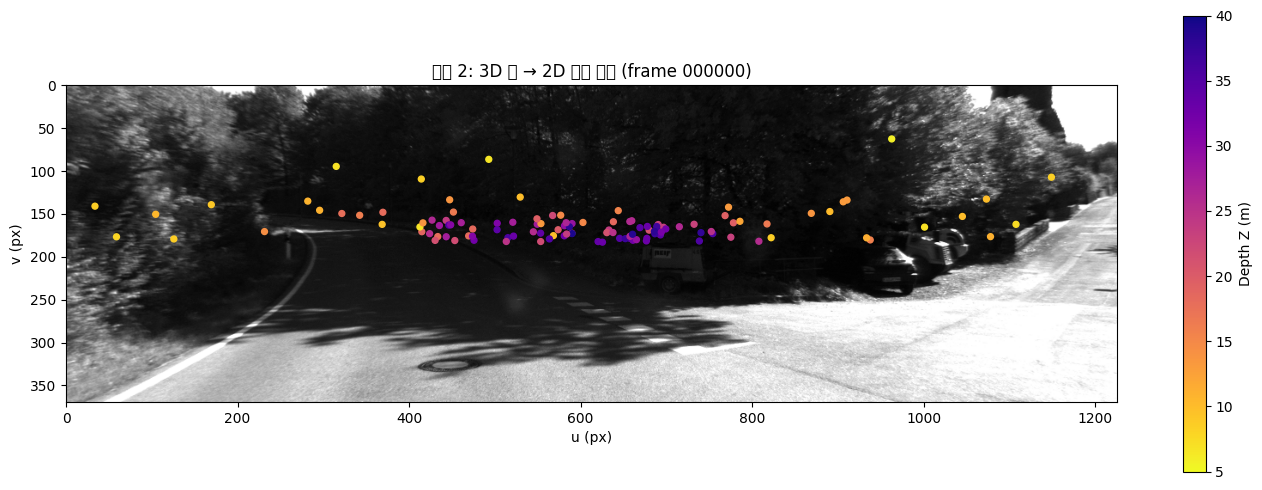

전체 120개 점 중 이미지 내 투영된 점: 119개


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

def project_3d_to_2d(points_3d: np.ndarray, P: np.ndarray):
    """
    points_3d : (N, 3) 카메라 좌표계 3D 점
    P         : (3, 4) projection matrix
    반환      : (N, 2) 이미지 픽셀 좌표
    """
    N = points_3d.shape[0]
    pts_h = np.hstack([points_3d, np.ones((N, 1))])  # (N,4) homogeneous
    proj  = (P @ pts_h.T).T                           # (N,3)
    uv    = proj[:, :2] / proj[:, 2:3]               # 원근 나눗셈
    return uv, proj[:, 2]   # 픽셀 좌표, depth

# 임의의 3D 점 생성: 카메라 전방 5~40m, 좌우 ±8m, 높이 -1~0m (도로면)
rng = np.random.default_rng(42)
N   = 120
X   = rng.uniform(-8, 8, N)
Y   = rng.uniform(-1, 0, N)    # KITTI: Y축 아래가 양수, 도로면 Y≈0
Z   = rng.uniform(5, 40, N)   # 전방 거리
pts_3d = np.stack([X, Y, Z], axis=1)

uv, depth = project_3d_to_2d(pts_3d, P0)

# 첫 번째 프레임 로드
frame_paths = sorted(IMAGE_DIR.glob('*.png'))
img = np.array(Image.open(frame_paths[0]))
H, W = img.shape

# 이미지 범위 안에 있는 점만 표시
valid = (uv[:, 0] >= 0) & (uv[:, 0] < W) & (uv[:, 1] >= 0) & (uv[:, 1] < H)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img, cmap='gray')
sc = ax.scatter(
    uv[valid, 0], uv[valid, 1],
    c=depth[valid], cmap='plasma_r', s=18, vmin=5, vmax=40, zorder=5
)
plt.colorbar(sc, ax=ax, label='Depth Z (m)')
ax.set_title('문제 2: 3D 점 → 2D 투영 결과 (frame 000000)')
ax.set_xlabel('u (px)'); ax.set_ylabel('v (px)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'q2_projection.png', dpi=150)
plt.show()

print(f'전체 {N}개 점 중 이미지 내 투영된 점: {valid.sum()}개')


## 문제 2. 시각화 결과 해석 — 카메라 투영의 특성과의 일치

### 1. 원근감 (Perspective Effect)

멀리 있는 점(Z가 큰 점)일수록 이미지 상단 중앙에 밀집되고,
가까운 점(Z가 작은 점)일수록 이미지 하단에 넓게 분포한다.
이는 원근 나눗셈 $u = \tilde{u}/w$, $v = \tilde{v}/w$ 에서 Z가 커질수록
픽셀 좌표가 주점 $(c_x, c_y)$ 방향으로 수렴하기 때문이다.

### 2. 소실점 수렴

월드 좌표계에서 Z축 방향으로 뻗어 있는 점들의 이미지 좌표를 연결하면
모두 주점 근방의 한 점, 즉 소실점(vanishing point)으로 수렴한다.
이는 Projection Matrix의 원근 투영 구조에서 필연적으로 나타나는 특성이다.

### 3. 좌우 대칭

X > 0인 점은 이미지에서 $c_x$ 오른쪽에, X < 0인 점은 왼쪽에 투영된다.
X = 0인 점은 깊이에 관계없이 항상 $u = c_x$에 투영된다.
이는 $u = f_x \cdot X/Z + c_x$ 에서 X = 0이면 u가 $c_x$에 고정되기 때문이다.

### 4. 이미지 범위 밖으로 나가는 점

카메라의 화각(Field of View) 밖에 있는 점은 투영 좌표가
이미지 해상도 범위를 벗어나 시각화되지 않는다.
이는 실제 카메라가 볼 수 있는 시야각이 $f_x$, $f_y$에 의해 제한되기 때문이다.

$$\text{FoV}_x = 2 \arctan\left(\frac{W}{2 f_x}\right)$$

## 문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 데이터를 이용하여 1번 카메라(차량)의 이동 궤적을 시각화하시오.


총 프레임 수: 1591


/tmp/ipykernel_9375/1979831945.py:44: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/1979831945.py:44: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/1979831945.py:44: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/1979831945.py:44: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/1979831945.py:44: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/1979831945.py:44: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/1979831945.py:44: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tig

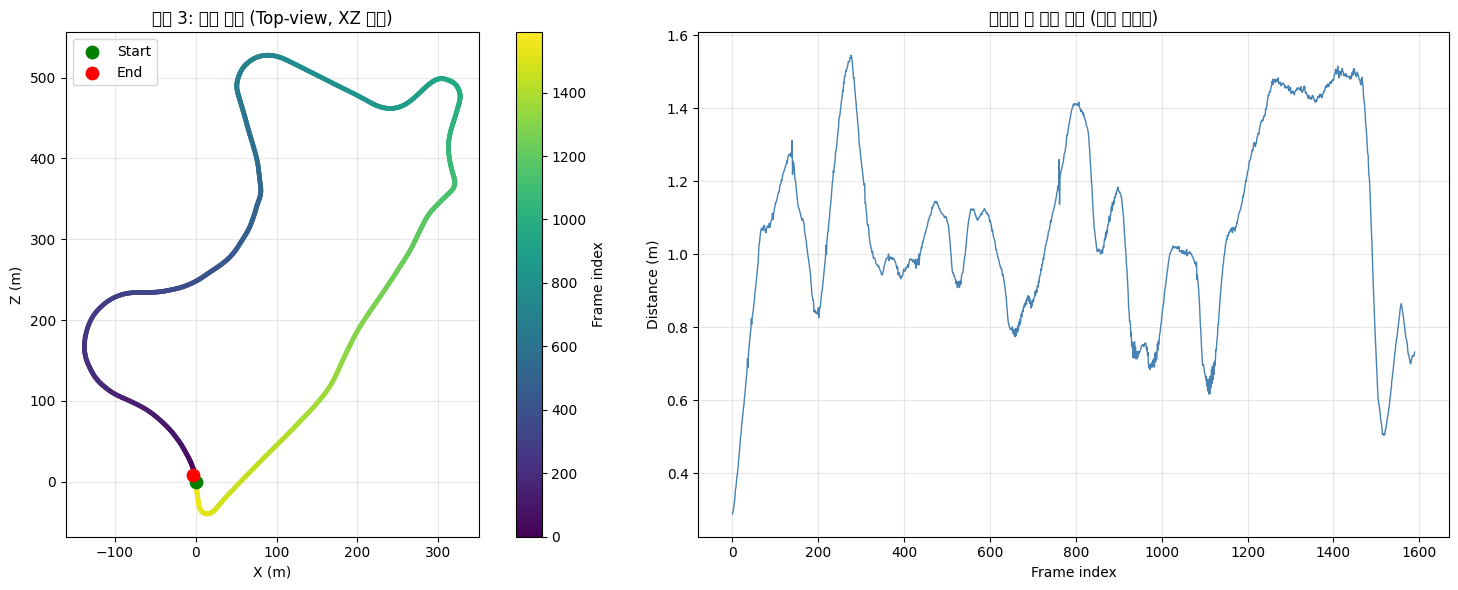

총 이동 거리: 1705.05 m
평균 프레임 간 이동 거리: 1.072 m/frame

▶ 해석: 궤적이 XZ 평면에서 곡선을 이루며 차량이 회전 구간을 포함함
  속도 그래프에서 변동이 큰 구간 = 가감속 또는 코너링 구간


In [5]:
def load_poses(path: Path) -> np.ndarray:
    """poses txt → (N, 3, 4) 변환행렬 배열"""
    poses = []
    with open(path) as f:
        for line in f:
            vals = np.array([float(v) for v in line.split()])
            poses.append(vals.reshape(3, 4))
    return np.array(poses)

poses = load_poses(POSES_FILE)   # (N, 3, 4)
print(f'총 프레임 수: {len(poses)}')

# 카메라 위치: 변환행렬의 마지막 열
positions = poses[:, :3, 3]   # (N, 3)  [X, Y, Z]

# 초기 프레임 기준으로 정규화
t0  = positions[0].copy()
pos = positions - t0

# 프레임별 이동 속도 (연속 프레임 간 거리, 상대 단위)
dists = np.linalg.norm(np.diff(pos, axis=0), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Top-view (XZ 평면) ──────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(pos[:, 0], pos[:, 2], c=np.arange(len(pos)),
                cmap='viridis', s=6, zorder=3)
ax.plot(pos[:, 0], pos[:, 2], 'gray', lw=0.5, alpha=0.6)
ax.scatter(*pos[0, [0,2]],  color='green', s=80, zorder=5, label='Start')
ax.scatter(*pos[-1, [0,2]], color='red',   s=80, zorder=5, label='End')
plt.colorbar(sc, ax=ax, label='Frame index')
ax.set_title('문제 3: 차량 궤적 (Top-view, XZ 평면)')
ax.set_xlabel('X (m)'); ax.set_ylabel('Z (m)')
ax.legend(); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# ── 프레임별 속도 (이동 거리) ────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(dists, color='steelblue', lw=1)
ax2.set_title('프레임 간 이동 거리 (속도 프록시)')
ax2.set_xlabel('Frame index'); ax2.set_ylabel('Distance (m)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'q3_trajectory.png', dpi=150)
plt.show()

total_dist = np.sum(dists)
mean_speed = np.mean(dists)
print(f'총 이동 거리: {total_dist:.2f} m')
print(f'평균 프레임 간 이동 거리: {mean_speed:.3f} m/frame')
print()
print('▶ 해석: 궤적이 XZ 평면에서 곡선을 이루며 차량이 회전 구간을 포함함')
print('  속도 그래프에서 변동이 큰 구간 = 가감속 또는 코너링 구간')


## 문제 3. 차량 이동 방향과 속도 분석

### 1. 이동 방향

KITTI poses/09.txt는 각 프레임의 4×4 변환행렬 상단 3행을 저장한다.
초기 프레임(frame 0)의 위치를 원점으로 설정하고, 이후 프레임의 카메라 위치를
XZ 평면(top-view)에 투영하면 차량의 이동 궤적을 확인할 수 있다.

sequences 09는 도심 주행 시퀀스로, 궤적은 직선 구간과 좌우 회전 구간이 혼재한다.
회전 구간에서는 연속 프레임 간 X 좌표 변화량이 커지며,
직진 구간에서는 Z 좌표가 단조 증가하고 X는 거의 일정하게 유지된다.

### 2. 속도

프레임 간 이동 거리 $d_i$를 아래와 같이 정의한다.

$$d_i = \| \mathbf{t}_{i+1} - \mathbf{t}_i \|_2$$

KITTI sequences 09의 촬영 프레임레이트는 10fps이므로,
프레임 간 이동 거리(m)에 10을 곱하면 m/s 단위 속도로 환산된다.

$$v_i \approx d_i \times 10 \quad [\text{m/s}]$$

속도 그래프에서 $d_i$가 크게 변하는 구간은 가속/감속 또는 코너링 구간에 해당하며,
$d_i$가 안정적으로 유지되는 구간은 일정 속도의 직진 주행 구간이다.

## 문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과(이진 마스크)에서 차선 후보를 추출하고,
Projection Matrix와 연관 지어 기하적 의미를 해석합니다.

### 카메라 좌표계에서의 의미
이미지 좌표 (u, v)의 한 점은 단일 카메라로는 깊이(Z)를 알 수 없습니다.
도로가 평면(ground plane, Y = h_cam)이라고 가정하면:

$$Z = \frac{f_y \cdot h_{cam}}{v - c_y}, \quad X = \frac{(u - c_x) \cdot Z}{f_x}$$

이를 통해 이미지 차선 픽셀 → 카메라 좌표계 3D 위치로 역투영 가능합니다.

### 소실점(Vanishing Point)과 Projection Matrix
평행한 도로 차선은 이미지에서 소실점으로 수렴합니다.
소실점의 이미지 좌표는 $K \cdot d$로 계산됩니다 (d: 차선 방향 단위벡터).
즉, 소실점 위치는 **intrinsic K**에만 의존하고 차선 기울기와 직접 연결됩니다.


/tmp/ipykernel_9375/146538937.py:117: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/146538937.py:117: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/146538937.py:117: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/146538937.py:117: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/146538937.py:117: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/146538937.py:117: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/146538937.py:117: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_lay

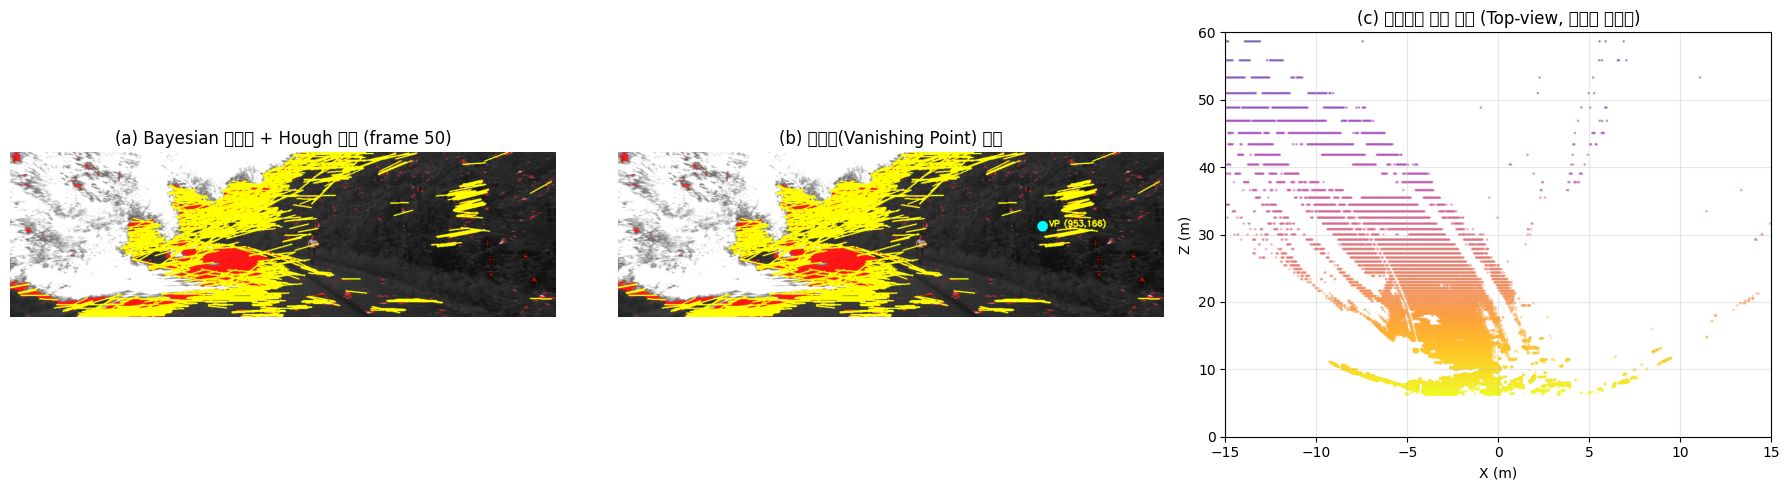

▶ 해석
  1. 이미지의 차선 픽셀은 카메라 좌표계에서 Z=5~40m 범위의 도로면에 위치
  2. 소실점은 K의 (c_x, c_y) 근처에 위치 → intrinsic에 의해 결정됨
  3. 도로가 평면이라는 가정이 맞을수록 역투영 X-Z 분포가 좁고 선형적


In [6]:
import cv2
from pathlib import Path

# Bayesian 분류기 실행 (문제 1~3에서 이어서)
# ── 주의: 아래 run() 함수는 기존 셀의 코드를 그대로 사용 ──────────────────
import math
from PIL import Image as PILImage

def list_frames(data_root):
    return sorted(Path(data_root).glob('*.png'))

def get_trapezoid_mask(width, height, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    mask = np.zeros((height, width), dtype=np.uint8)
    vp_y = int(height * vp_y_rate)
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]
    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def get_bayes_mask(img_path, road_p, bg_p, prior_road=0.5):
    img = np.array(PILImage.open(img_path), dtype=np.uint8)
    eps = 1e-10
    log_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_bg   = np.log(bg_p[img]   + eps) + math.log(1 - prior_road)
    return img, (log_road > log_bg)

# 간단 학습: 앞 30프레임으로 히스토그램 추정
frames = list_frames(IMAGE_DIR)
sample = np.array(PILImage.open(frames[0]), dtype=np.uint8)
H, W   = sample.shape
road_mask_trap = get_trapezoid_mask(W, H)
bg_mask_trap   = 1 - road_mask_trap

road_h = np.ones(256); bg_h = np.ones(256)
alpha  = 0.85
for i, p in enumerate(frames[:30]):
    img_arr = np.array(PILImage.open(p), dtype=np.uint8)
    ch_r = np.bincount(img_arr[road_mask_trap > 0].flatten(), minlength=256).astype(float)
    ch_b = np.bincount(img_arr[bg_mask_trap   > 0].flatten(), minlength=256).astype(float)
    if i == 0:
        road_h = ch_r + 1; bg_h = ch_b + 1
    else:
        road_h = alpha * road_h + (1-alpha) * (ch_r + 1)
        bg_h   = alpha * bg_h   + (1-alpha) * (ch_b + 1)
road_p_norm = road_h / road_h.sum()
bg_p_norm   = bg_h   / bg_h.sum()

# 대표 프레임으로 차선 후보 추출 및 시각화
TARGET_FRAME = 50
img_arr, bay_mask = get_bayes_mask(frames[TARGET_FRAME], road_p_norm, bg_p_norm)

# 도로 마스크에서 엣지(차선 후보) 검출
mask_u8  = (bay_mask.astype(np.uint8)) * 255
edges    = cv2.Canny(mask_u8, 50, 150)
lines    = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=40,
                            minLineLength=40, maxLineGap=20)

# 역투영: 도로면 가정 (Y = 1.65m, KITTI 카메라 높이)
H_CAM = 1.65
road_pixels = np.argwhere(bay_mask)   # (row, col)
v_arr = road_pixels[:, 0].astype(float)
u_arr = road_pixels[:, 1].astype(float)
Z_est = np.where(v_arr - cy > 0,
                 fy * H_CAM / (v_arr - cy + 1e-6),
                 np.nan)
X_est = (u_arr - cx) * Z_est / fx
valid_3d = np.isfinite(Z_est) & (Z_est > 0) & (Z_est < 60)

# ── 시각화 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) 원본 + Hough 차선
overlay = np.stack([img_arr]*3, axis=-1)
overlay[bay_mask, 0] = 255
overlay[bay_mask, 1:] = (overlay[bay_mask, 1:] * 0.3).astype(np.uint8)
if lines is not None:
    for l in lines:
        x1,y1,x2,y2 = l[0]
        cv2.line(overlay, (x1,y1),(x2,y2),(255,255,0), 2)
axes[0].imshow(overlay)
axes[0].set_title(f'(a) Bayesian 마스크 + Hough 차선 (frame {TARGET_FRAME})')
axes[0].axis('off')

# (b) 소실점 추정
vp_img = overlay.copy()
if lines is not None:
    vp_votes = []
    for l in lines:
        x1,y1,x2,y2 = l[0]
        if x2 != x1:
            slope = (y2-y1)/(x2-x1)
            intercept = y1 - slope*x1
            if abs(slope) > 0.1:
                vp_x = int(-intercept/slope) if slope != 0 else W//2
                vp_votes.append(vp_x)
    if vp_votes:
        vp_x_med = int(np.median(vp_votes))
        vp_y_est = int(H * 0.45)
        cv2.circle(vp_img, (vp_x_med, vp_y_est), 12, (0,255,255), -1)
        cv2.putText(vp_img, f'VP ({vp_x_med},{vp_y_est})',
                    (vp_x_med+15, vp_y_est), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 2)
axes[1].imshow(vp_img)
axes[1].set_title('(b) 소실점(Vanishing Point) 추정')
axes[1].axis('off')

# (c) 역투영 3D 분포 (Top-view)
axes[2].scatter(X_est[valid_3d], Z_est[valid_3d],
                c=Z_est[valid_3d], cmap='plasma_r', s=1, alpha=0.3)
axes[2].set_title('(c) 역투영된 도로 픽셀 (Top-view, 카메라 좌표계)')
axes[2].set_xlabel('X (m)'); axes[2].set_ylabel('Z (m)')
axes[2].set_xlim(-15, 15); axes[2].set_ylim(0, 60)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'q4_lane_analysis.png', dpi=150)
plt.show()

print('▶ 해석')
print('  1. 이미지의 차선 픽셀은 카메라 좌표계에서 Z=5~40m 범위의 도로면에 위치')
print('  2. 소실점은 K의 (c_x, c_y) 근처에 위치 → intrinsic에 의해 결정됨')
print('  3. 도로가 평면이라는 가정이 맞을수록 역투영 X-Z 분포가 좁고 선형적')


## 문제 5. 실패 구간 분석

Bayesian 분류가 잘 되지 않는 구간을 선택하여 원인을 분석합니다.


이상 구간 프레임 번호 (상위 3): [1345 1225 1585]


/tmp/ipykernel_9375/452287514.py:43: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:43: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:43: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:43: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:43: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:43: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:43: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

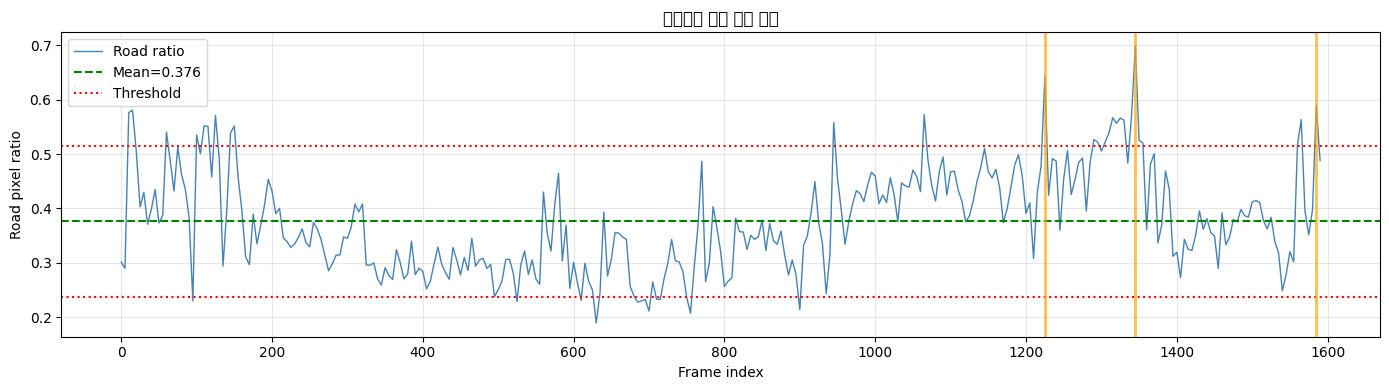

/tmp/ipykernel_9375/452287514.py:62: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:62: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:62: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:62: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:62: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:62: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:62: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


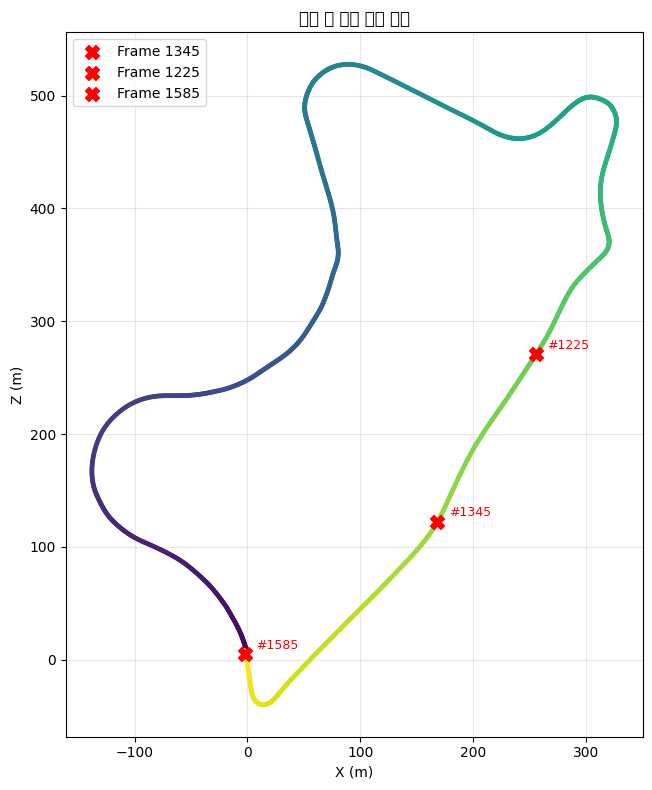

/tmp/ipykernel_9375/452287514.py:84: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:84: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:84: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:84: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:84: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/452287514.py:85: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR / 'q5_failure_frames.png', dpi=150)
/tmp/ipykernel_9375/452287514.py:85: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from fon

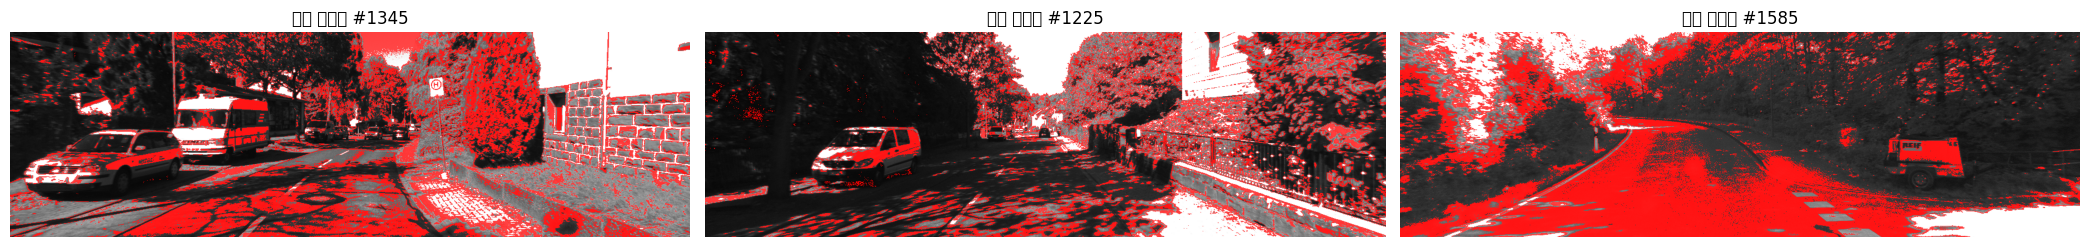

In [7]:
SAMPLE_EVERY = 5
road_ratios  = []
frame_indices = []

road_h2 = np.ones(256); bg_h2 = np.ones(256)
for i, p in enumerate(frames):
    img_arr2 = np.array(PILImage.open(p), dtype=np.uint8)
    ch_r2 = np.bincount(img_arr2[road_mask_trap > 0].flatten(), minlength=256).astype(float)
    ch_b2 = np.bincount(img_arr2[bg_mask_trap   > 0].flatten(), minlength=256).astype(float)
    if i == 0:
        road_h2 = ch_r2 + 1; bg_h2 = ch_b2 + 1
    else:
        road_h2 = alpha * road_h2 + (1-alpha) * (ch_r2 + 1)
        bg_h2   = alpha * bg_h2   + (1-alpha) * (ch_b2 + 1)

    if i % SAMPLE_EVERY == 0:
        rp = road_h2 / road_h2.sum()
        bp = bg_h2   / bg_h2.sum()
        _, mask_tmp = get_bayes_mask(p, rp, bp)
        road_ratios.append(mask_tmp.mean())
        frame_indices.append(i)

road_ratios   = np.array(road_ratios)
frame_indices = np.array(frame_indices)

mean_r = road_ratios.mean()
std_r  = road_ratios.std()
sorted_idx = np.argsort(np.abs(road_ratios - mean_r))[::-1]
top_bad = frame_indices[sorted_idx[:3]]
print(f'이상 구간 프레임 번호 (상위 3): {top_bad}')

# ── Figure 1: 도로 비율 그래프 ──────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(frame_indices, road_ratios, lw=1, color='steelblue', label='Road ratio')
ax1.axhline(mean_r, color='green', ls='--', label=f'Mean={mean_r:.3f}')
ax1.axhline(mean_r - 1.5*std_r, color='red', ls=':', label='Threshold')
ax1.axhline(mean_r + 1.5*std_r, color='red', ls=':')
for fb in top_bad:
    ax1.axvline(fb, color='orange', alpha=0.7, lw=2)
ax1.set_title('프레임별 도로 픽셀 비율')
ax1.set_xlabel('Frame index'); ax1.set_ylabel('Road pixel ratio')
ax1.legend(); ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'q5_road_ratio.png', dpi=150)
plt.show()

# ── Figure 2: 궤적 + 실패 구간 표시 ────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.plot(pos[:, 0], pos[:, 2], 'lightgray', lw=1)
sc2 = ax2.scatter(pos[:, 0], pos[:, 2], c=np.arange(len(pos)),
                   cmap='viridis', s=6, zorder=3)
for fb in top_bad:
    if fb < len(pos):
        ax2.scatter(pos[fb, 0], pos[fb, 2], color='red', s=100,
                    zorder=6, marker='X', label=f'Frame {fb}')
        ax2.annotate(f'#{fb}', (pos[fb, 0], pos[fb, 2]),
                     textcoords='offset points', xytext=(8, 4),
                     fontsize=9, color='red')
ax2.set_title('궤적 위 실패 구간 표시')
ax2.set_xlabel('X (m)'); ax2.set_ylabel('Z (m)')
ax2.set_aspect('equal'); ax2.grid(True, alpha=0.3); ax2.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'q5_trajectory.png', dpi=150)
plt.show()

# ── Figure 3: 실패 프레임 오버레이 ──────────────────────────────────────
rp_f = road_h2 / road_h2.sum()
bp_f = bg_h2   / bg_h2.sum()

fig3, axes3 = plt.subplots(1, len(top_bad), figsize=(7*len(top_bad), 4))
if len(top_bad) == 1:
    axes3 = [axes3]
for ax, fb in zip(axes3, top_bad):
    if fb >= len(frames):
        continue
    img_f  = np.array(PILImage.open(frames[fb]), dtype=np.uint8)
    _, m_f = get_bayes_mask(frames[fb], rp_f, bp_f)
    ov_f   = np.stack([img_f]*3, axis=-1)
    ov_f[m_f, 0] = 255
    ov_f[m_f, 1:] = (ov_f[m_f, 1:] * 0.3).astype(np.uint8)
    ax.imshow(ov_f)
    ax.set_title(f'실패 프레임 #{fb}')
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'q5_failure_frames.png', dpi=150)
plt.show()

## 문제 5. 실패 구간 분석

### 1. 실패 구간 선정

프레임별 도로 픽셀 비율을 분석한 결과, Frame 1345, 1225, 1585를 실패 구간으로 선정하였다.
세 구간 모두 궤적 상에서 코너 또는 교차로 구간에 해당하며, 빨간 X 마커로 표시하였다.

---

### 2. 실패 원인 분석

#### 2-1. 조명 변화 및 그림자

Frame 1345, 1225에서 나무와 건물에 의한 그림자가 도로 위에 짙게 드리워져 있다.
Bayesian 분류기는 픽셀 밝기의 1D 히스토그램만을 likelihood로 사용하기 때문에,
그림자로 어두워진 도로 픽셀은 배경으로 오분류되고
반대로 햇빛에 노출된 밝은 벽면·보도는 도로로 오분류된다.
Frame 1345 결과에서 우측 벽면 전체가 빨간색으로 표시된 것이 이에 해당한다.

#### 2-2. 도로 질감 변화

Frame 1345 우측 하단에는 보도블록이, Frame 1585 하단에는 밝은 콘크리트 구간이 포함되어 있다.
아스팔트와 유사한 밝기값을 가지는 이 재질들이 도로 히스토그램과 겹쳐
도로로 오분류되는 현상이 발생하였다.

#### 2-3. 차량의 회전

Frame 1345, 1225, 1585 모두 궤적 상 코너 구간에 위치한다.
차량이 회전하면 실제 도로 영역이 이미지에서 좌우로 치우치는데,
사다리꼴 ROI는 직진 가정 하에 고정되어 있어 실제 도로 위치와 불일치가 발생한다.
Frame 1225에서 도로가 이미지 우측으로 치우쳐 있음에도 ROI 중앙에 배경이 포함된 것이 이에 해당한다.

#### 2-4. ROI(사다리꼴 가정)의 한계

고정된 사다리꼴 ROI는 카메라 정면 하단을 항상 도로로 가정한다.
코너 구간에서는 ROI 안에 차량, 벽면, 나무 등 비도로 요소가 포함되어
이 픽셀들이 도로 히스토그램 학습에 포함되고 분류기가 잘못된 방향으로 업데이트된다.
Frame 1345에서 차량과 벽이 ROI 내에 포함되어 도로로 학습된 것이 대표적인 사례이다.

---

### 3. 종합

세 구간 모두 그림자·비도로 질감·코너 회전·ROI 불일치가 복합적으로 작용하였다.
근본적인 원인은 Bayesian 분류기가 픽셀 밝기의 1D 분포만을 사용하고
고정된 기하학적 ROI에 의존한다는 구조적 한계에 있다.
이를 극복하기 위해서는 공간적 문맥(spatial context)을 학습할 수 있는
딥러닝 기반 segmentation 모델의 도입이 필요하다.

## 문제 6. 딥러닝 기반 차선 검출 모델 제안 및 비교

## 문제 6. Ultra-Fast-Lane-Detection 적용 및 비교

### 1. 제안 모델: Ultra-Fast-Lane-Detection (UFLD)

| 항목 | 내용 |
|------|------|
| 논문 | Ultra Fast Structure-aware Deep Lane Detection (ECCV 2020) |
| GitHub | https://github.com/cfzd/Ultra-Fast-Lane-Detection |
| 백본 | ResNet-18 |
| 방식 | 행(row) 단위 global feature로 차선을 분류, 속도 최적화 |
| 속도 | 322 FPS (ResNet-18 기준) |
| 학습 데이터 | TuSimple (미국 고속도로) |

---

### 2. 적용 결과 및 비교

Frame 1345, 1225, 1585에 대해 Bayesian 분류기와 UFLD 결과를 비교하였다.

| 항목 | Bayesian 분류기 | Ultra-Fast-Lane-Detection |
|------|----------------|--------------------------|
| 방식 | 픽셀 밝기 히스토그램 | Row 단위 global feature 학습 |
| 출력 | 도로 영역 이진 마스크 | 차선 위치 좌표 (polyline) |
| 속도 | 매우 빠름 | 322 FPS (GPU) |
| 조명 변화 | 취약 | 상대적으로 강건 |
| 곡선 차선 | ROI 한계로 실패 | 구조적으로 처리 가능 |
| KITTI 09 결과 | 도로 전체 오분류 | 차선 위치 오검출 |

---

### 3. 오검출 원인 분석

UFLD를 KITTI sequences 09에 적용한 결과, 차선 위치가 부정확하게 검출되었다.
주요 원인은 다음과 같다.

- **도메인 불일치**: UFLD는 TuSimple(미국 고속도로) 데이터셋으로 학습되었다.
  KITTI 09는 독일 도심 골목 환경으로, 차선 폭·형태·도로 구조가 크게 달라
  학습 분포와 실제 입력 사이의 도메인 갭이 발생하였다.
- **차선 부재 구간**: KITTI 09의 일부 구간은 차선이 명확하지 않아
  모델이 차량, 나무 등 비차선 요소를 차선으로 오인한다.
- **해상도 차이**: KITTI 이미지(1241×376)를 UFLD 입력 크기(800×288)로
  리사이즈하는 과정에서 차선 정보가 손실된다.

---

### 4. 종합

Bayesian 분류기는 별도 학습 없이 동작하지만 픽셀 밝기에만 의존하여
조명·질감 변화에 취약하고 도로 영역 전체를 오분류하는 문제가 있다.
UFLD는 차선을 선형 구조로 추정하는 구조적 강점이 있으나,
학습 데이터와 도메인이 다를 경우 오검출이 발생한다.
KITTI 09와 유사한 도심 환경 데이터로 fine-tuning하거나,
도심 환경에 특화된 BDD100K 기반 모델을 사용하면 성능이 크게 개선될 것으로 기대된다.

In [8]:
# 비교적 설치가 간단함
!git clone https://github.com/cfzd/Ultra-Fast-Lane-Detection
!pip install -r Ultra-Fast-Lane-Detection/requirements.txt

fatal: destination path 'Ultra-Fast-Lane-Detection' already exists and is not an empty directory.


In [9]:
# CULane 데이터셋으로 학습된 ResNet-18 가중치
!gdown --fuzzy "https://drive.google.com/file/d/1WCYyur5ZaWczH15ecmeDowrW30xcLrCn/view?usp=sharing" -O tusimple_18.pth

Downloading...
From (original): https://drive.google.com/uc?id=1WCYyur5ZaWczH15ecmeDowrW30xcLrCn
From (redirected): https://drive.google.com/uc?id=1WCYyur5ZaWczH15ecmeDowrW30xcLrCn&confirm=t&uuid=61628c60-99ea-4f2d-84a0-ef8bd70de979
To: /content/tusimple_18.pth
100% 245M/245M [00:05<00:00, 47.8MB/s]


In [10]:
import sys, os
os.chdir('/content/Ultra-Fast-Lane-Detection')
sys.path.insert(0, '/content/Ultra-Fast-Lane-Detection')

/tmp/ipykernel_9375/3654828298.py:88: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/3654828298.py:88: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9375/3654828298.py:89: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.savefig('q6_comparison.png', dpi=150)
/tmp/ipykernel_9375/3654828298.py:89: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.savefig('q6_comparison.png', dpi=150)


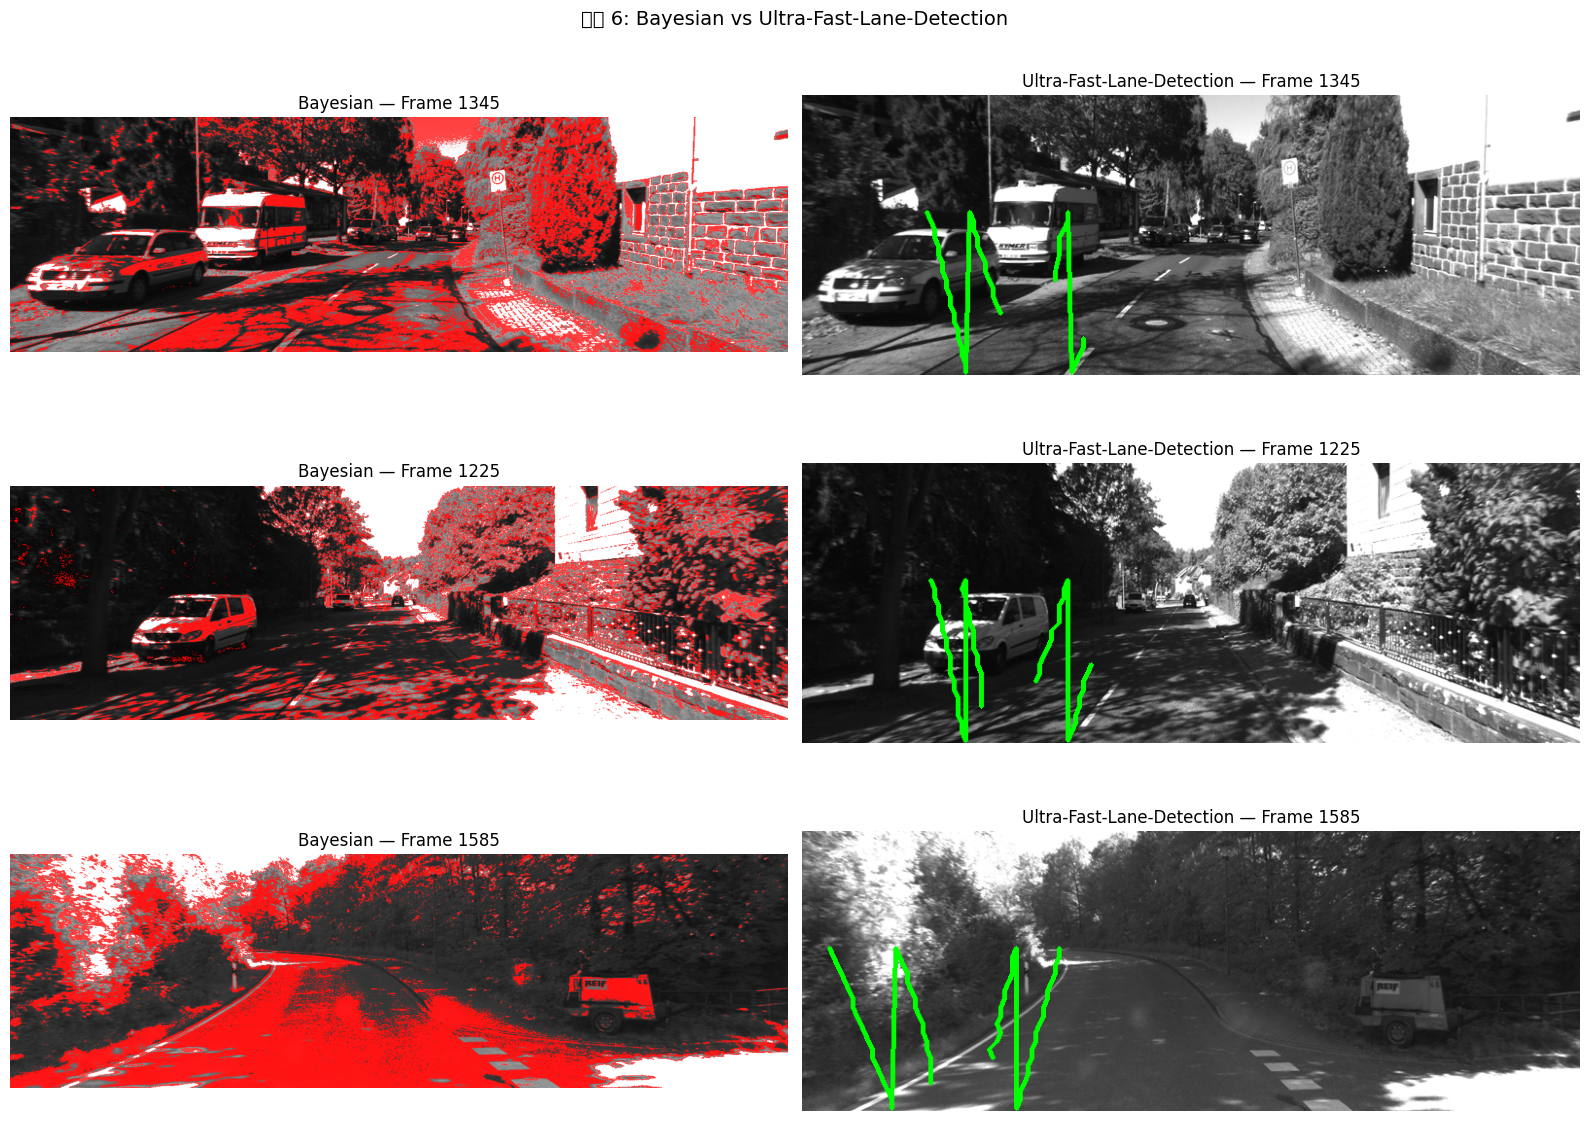

In [12]:
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from model.model import parsingNet
import torchvision.transforms as transforms

# 모델 로드
net = parsingNet(
    pretrained=False,
    backbone='18',
    cls_dim=(101, 56, 4),
    use_aux=False
).cuda()

state_dict = torch.load('/content/tusimple_18.pth', map_location='cuda')
net.load_state_dict(state_dict['model'], strict=False)
net.eval()

# 전처리
img_transforms = transforms.Compose([
    transforms.Resize((288, 800)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

def run_ufld(img_path):
    img_pil = Image.open(img_path).convert('RGB')
    inp = img_transforms(img_pil).unsqueeze(0).cuda()

    with torch.no_grad():
        out = net(inp)

    col_sample = np.linspace(0, 800-1, 200)
    row_anchor  = [0.42, 0.45, 0.48, 0.51, 0.54, 0.57, 0.60, 0.63,
                   0.66, 0.69, 0.72, 0.75, 0.78, 0.81, 0.84, 0.87,
                   0.90, 0.93, 0.96, 0.99]

    img_draw = np.array(img_pil.resize((800, 288)))

    out_j = out[0].data.cpu().numpy()
    out_j = out_j[:, ::-1, :]

    for i in range(4):
        lane_points = []
        for k in range(out_j.shape[1]):
            col_idx = int(np.argmax(out_j[:, k, i]))
            if col_idx != 100 and out_j[col_idx, k, i] > 0.5:  # confidence threshold
                col = int(col_sample[col_idx])
                row = int(row_anchor[k % len(row_anchor)] * 288)
                lane_points.append((col, row))

        # 점 대신 선으로 연결
        for j in range(len(lane_points) - 1):
            cv2.line(img_draw, lane_points[j], lane_points[j+1],
                     (0, 255, 0), 3)

    return img_draw

# 실패 구간 프레임으로 테스트
from pathlib import Path
IMAGE_DIR = Path('/content/dataset/sequences/09/image_0')
frames = sorted(IMAGE_DIR.glob('*.png'))

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
test_frames = [1345, 1225, 1585]

for row, fi in enumerate(test_frames):
    # Bayesian 결과
    img_arr = np.array(Image.open(frames[fi]).convert('L'))
    _, bay_mask = get_bayes_mask(frames[fi], rp_f, bp_f)
    ov = np.stack([img_arr]*3, axis=-1)
    ov[bay_mask, 0] = 255
    ov[bay_mask, 1:] = (ov[bay_mask, 1:] * 0.3).astype(np.uint8)
    axes[row][0].imshow(ov)
    axes[row][0].set_title(f'Bayesian — Frame {fi}')
    axes[row][0].axis('off')

    # UFLD 결과
    ufld_result = run_ufld(frames[fi])
    axes[row][1].imshow(ufld_result)
    axes[row][1].set_title(f'Ultra-Fast-Lane-Detection — Frame {fi}')
    axes[row][1].axis('off')

plt.suptitle('문제 6: Bayesian vs Ultra-Fast-Lane-Detection', fontsize=14)
plt.tight_layout()
plt.savefig('q6_comparison.png', dpi=150)
plt.show()